In [3]:
"""
El Script Sobel gradient maps scientific interfaces, tiene como objetivo es entender como Sobel gradient calcula y porque detecta las interfaces en imagenes.

Gradiente de imagenes

Si la imagenes estan representadas por intensidades I(x,y),
entonces se puede representar de la siguiente manera:

∇I(x,y) = (∂I/∂x , ∂I/∂y)

Esto mide cuan rapido cambian los gradientes.

In images:

Bajo gradiente → region uniforme  
Alto gradiente → interfase

## Operador Sobel 

Sobel aproxima las derivadas usando la convolucion de ker. 

Sobel X kernel:

[-1 0 1
 -2 0 2
 -1 0 1]

Sobel Y kernel:

[-1 -2 -1
  0  0  0
  1  2  1]
  
De ahi se calcula la magnitud del gradiente:

|∇I| = sqrt(Gx² + Gy²)

"""


'\nEl Script Sobel gradient maps scientific interfaces, tiene como objetivo es entender como Sobel gradient calcula y porque detecta las interfaces en imagenes.\n\nGradiente de imagenes\n\nSi la imagenes estan representadas por intensidades I(x,y),\nentonces se puede representar de la siguiente manera:\n\n∇I(x,y) = (∂I/∂x , ∂I/∂y)\n\nEsto mide cuan rapido cambian los gradientes.\n\nIn images:\n\nBajo gradiente → region uniforme  \nAlto gradiente → interfase\n\n## Operador Sobel \n\nSobel aproxima las derivadas usando la convolucion de ker. \n\nSobel X kernel:\n\n[-1 0 1\n -2 0 2\n -1 0 1]\n\nSobel Y kernel:\n\n[-1 -2 -1\n  0  0  0\n  1  2  1]\n\nDe ahi se calcula la magnitud del gradiente:\n\n|∇I| = sqrt(Gx² + Gy²)\n\n'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pathlib import Path
from skimage.draw import disk, rectangle
from skimage.util import random_noise

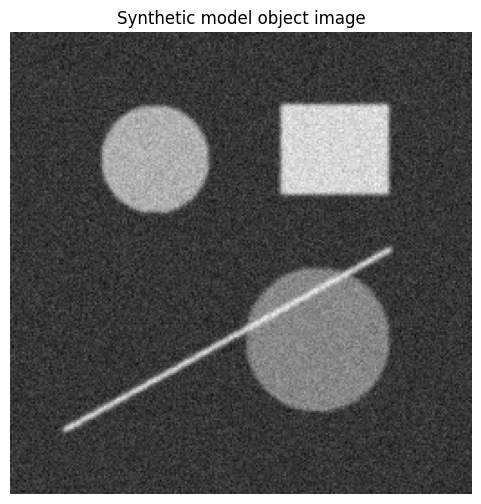

In [9]:
np.random.seed(42)

img = np.ones((256,256), dtype=np.float32) * 0.25

rr, cc = disk((70,80), 30, shape=img.shape)
img[rr,cc] = 0.70

rr, cc = disk((170,170), 40, shape=img.shape)
img[rr,cc] = 0.55

start = (40,150)
extent = (50,60)
rr, cc = rectangle(start=start, extent=extent, shape=img.shape)
img[rr,cc] = 0.85

cv2.line(img,(30,220),(210,120), color=0.95, thickness=2)

img_blur = cv2.GaussianBlur(img,(5,5),0)

img_noisy = random_noise(img_blur, mode='gaussian', var=0.002)
img_noisy = img_noisy.astype(np.float32)

plt.figure(figsize=(6,6))
plt.imshow(img_noisy, cmap='gray')
plt.title("Synthetic model object image")
plt.axis("off")
plt.savefig("../figures/figures_sobel/syntetic_image.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
sobel_x = cv2.Sobel(img_noisy, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_noisy, cv2.CV_64F, 0, 1, ksize=3)

print(sobel_x.shape)
print(sobel_y.shape)

(256, 256)
(256, 256)


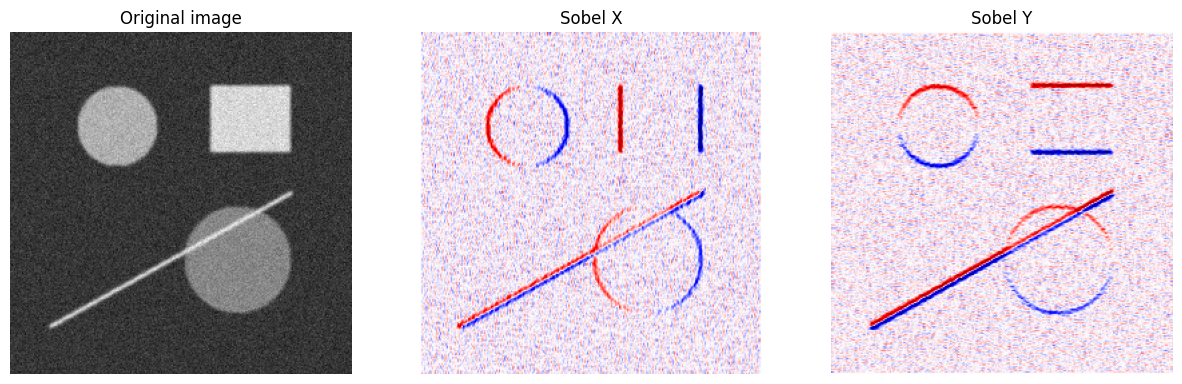

In [10]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(sobel_x, cmap='seismic')
axes[1].set_title("Sobel X")
axes[1].axis("off")

axes[2].imshow(sobel_y, cmap='seismic')
axes[2].set_title("Sobel Y")
axes[2].axis("off")

plt.savefig("../figures/figures_sobel/syntetic_model_and_seismics_responses.png", dpi=300, bbox_inches="tight")
plt.show()

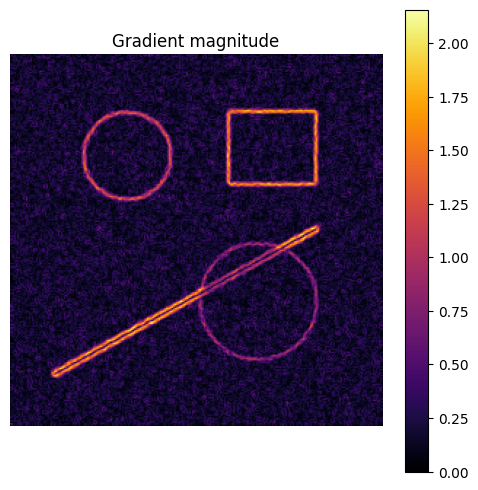

In [8]:
grad_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.figure(figsize=(6,6))
plt.imshow(grad_magnitude, cmap='inferno')
plt.title("Gradient magnitude")
plt.axis("off")
plt.colorbar()
plt.show()

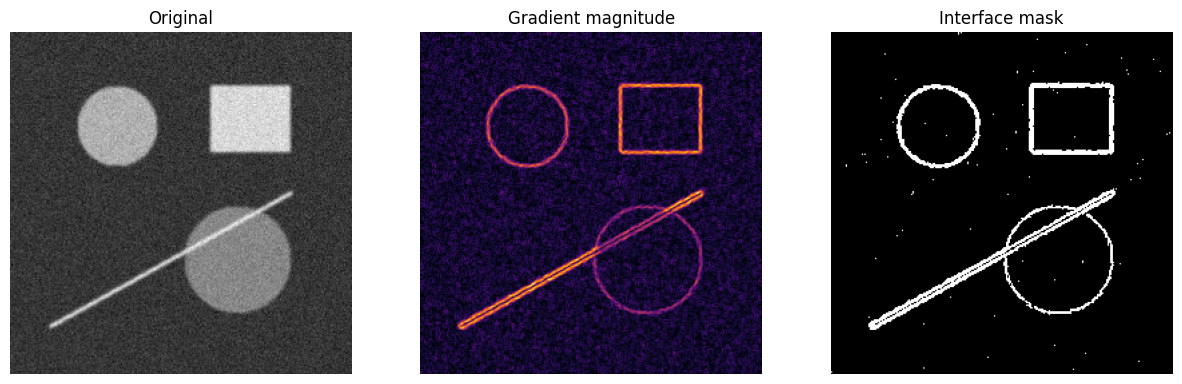

In [22]:
grad_norm = cv2.normalize(grad_magnitude, None, 0, 1, cv2.NORM_MINMAX)

threshold = 0.26

interface_mask = (grad_norm > threshold).astype(np.uint8)

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(grad_norm, cmap='inferno')
axes[1].set_title("Gradient magnitude")

axes[2].imshow(interface_mask, cmap='gray')
axes[2].set_title("Interface mask")

for ax in axes:
    ax.axis("off")
plt.savefig("../figures/figures_sobel/syntetic_gradient_manitude_interface_mask.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
"""
Ahora vamos a hacer una detección automtica de las interfaces desde el gradiente de magnitud

El mapa de gradientes lo pasamos a un detector binario de gradientes.

Idea basica:
Gradiente alto → interface
Gradiente bajo → region homegenea
"""

'\nAhora vamos a hacer una detección automtica de las interfaces desde el gradiente de magnitud\n\nEl mapa de gradientes lo pasamos a un detector binario de gradientes.\n\nIdea basica:\nGradiente alto → interface\nGradiente bajo → region homegenea\n'